# Importing libraries

In [3]:
from pathlib import Path
from tabulate import tabulate
import matplotlib.pyplot as plt 

# Basic wrangling and external features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# For linear models
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import PoissonRegressor

#For tree-based models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# Set up and feature selection

In [4]:
# Full model parquet 
DATA_PATH = Path("../outputs/ecobici_prediction_panel.parquet")
model_df = pd.read_parquet(DATA_PATH)

print(model_df.shape)
model_df.head()

(21735186, 27)


,station_id,datetime_hour,departures,arrivals,net_flow,abs_net_flow,year,month,day,hour,...,is_raining,is_holiday,holiday_name,lat,lon,capacity,nearest_metro_name,distance_to_metro_m,lag_1,lag_24
0,1,2018-01-02 13:00:00,11,12,-1,1,2018,1,2,13,...,0,0,None,19.416795,-99.192508,39.0,Constituyentes,573.702169,8.0,0.0
1,1,2018-01-02 14:00:00,11,13,-2,2,2018,1,2,14,...,0,0,None,19.416795,-99.192508,39.0,Constituyentes,573.702169,11.0,0.0
2,1,2018-01-02 15:00:00,9,12,-3,3,2018,1,2,15,...,0,0,None,19.416795,-99.192508,39.0,Constituyentes,573.702169,11.0,1.0
3,1,2018-01-02 16:00:00,10,10,0,0,2018,1,2,16,...,0,0,None,19.416795,-99.192508,39.0,Constituyentes,573.702169,9.0,4.0
4,1,2018-01-02 17:00:00,15,15,0,0,2018,1,2,17,...,0,0,None,19.416795,-99.192508,39.0,Constituyentes,573.702169,10.0,3.0


In [5]:
# Feature selection
model_df.columns.tolist()

['station_id',
 'datetime_hour',
 'departures',
 'arrivals',
 'net_flow',
 'abs_net_flow',
 'year',
 'month',
 'day',
 'hour',
 'weekday',
 'is_weekend',
 'is_morning_peak',
 'is_evening_peak',
 'date',
 'temperature',
 'rain',
 'is_raining',
 'is_holiday',
 'holiday_name',
 'lat',
 'lon',
 'capacity',
 'nearest_metro_name',
 'distance_to_metro_m',
 'lag_1',
 'lag_24']

In [6]:
# Target definition, including d_i, t or lagged demand with engineered features for weather, holidays and multimodality
features = [
    "hour",
    "weekday",
    "is_weekend",
    "is_morning_peak",
    "is_evening_peak",
    "month",
    "lag_1",
    "lag_24",
    "temperature",
    "rain",
    "is_raining",
    "is_holiday",
    "capacity",
    "distance_to_metro_m"
]

X = model_df[features] #excludes the target variable
y = model_df["departures"]

In [7]:
print("X columns:", X.columns.tolist())
print("y shape:", y.shape)
print("X shape:", X.shape)

X columns: ['hour', 'weekday', 'is_weekend', 'is_morning_peak', 'is_evening_peak', 'month', 'lag_1', 'lag_24', 'temperature', 'rain', 'is_raining', 'is_holiday', 'capacity', 'distance_to_metro_m']
y shape: (21735186,)
X shape: (21735186, 14)


- Features that could introduce leakage (such as arrivals, net flow and absolute net flow) have been excluded for demand prediction
- Imbalance will be considered in a specific function during optimization

In [9]:
# Time split, train and test separations: for the train 2018—2024 and test 2025 periods
train = model_df[model_df["year"] < 2025]
test  = model_df[model_df["year"] == 2025]

# Target variable (demand)
y_train = train["departures"]
y_test  = test["departures"]

# Select features
X_train = train[features]
X_test  = test[features]

# Scaling (needed for linear models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Linear Regression

In [10]:
# Fitting and predict model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

# Prediction 
y_pred_linear = linear_model.predict(X_test_scaled)
y_pred_linear = np.clip(y_pred_linear, 0, None)

In [11]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

results = []

results.append({
    "model": "Linear Regression",
    "MAE": mae_linear,
    "RMSE": rmse_linear,
    "total_true": y_test.sum(),
    "total_predicted": y_pred_linear.sum(),
    "bias_pct": (y_pred_linear.sum() - y_test.sum()) / y_test.sum()
})

results

[{'model': 'Linear Regression',
  'MAE': 2.4656976443635013,
  'RMSE': np.float64(3.695662370303975),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(16920626.344256945),
  'bias_pct': np.float64(-0.09312488996737703)}]

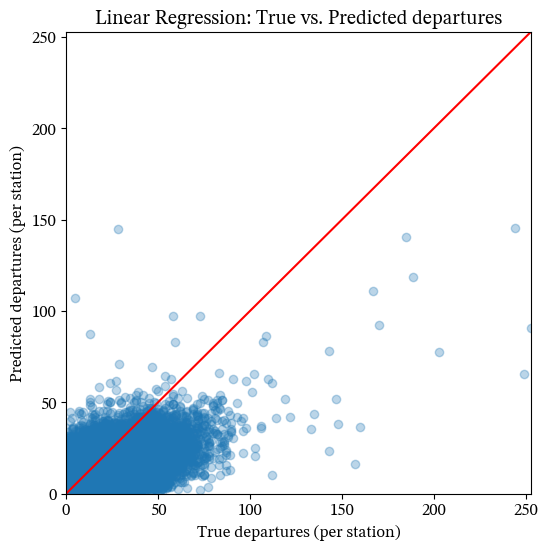

In [12]:
test_results = test.copy()
test_results["actual_departures"] = y_test
test_results["pred_departures_linear"] = y_pred_linear

# Linear plot
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIX Two Text"],
    "font.size": 12,
})

fig, ax = plt.subplots(figsize=(6,6))
plt.scatter(
    test_results["actual_departures"],
    test_results["pred_departures_linear"],
    alpha=0.3
)

plt.xlabel("True departures (per station)")
plt.ylabel("Predicted departures (per station)")
plt.title("Linear Regression: True vs. Predicted departures")

# perfect prediction line
max_val = max(test_results["actual_departures"].max(),
              test_results["pred_departures_linear"].max())

plt.plot([0, max_val], [0, max_val], color="red")
plt.xlim(0, max_val)
plt.ylim(0, max_val)

fig.savefig("../outputs/plots/linear_regression_pred.pdf", bbox_inches="tight")
plt.show()

- Baseline model (linear) shows stations with 50 departures are consistent in their prediction
- Stations that concentrate high demand seem to be underperforming, with several outliers (e.g. 250-300)
- The model is not capturing nonlinear demand patterns, such as peak-hour periods

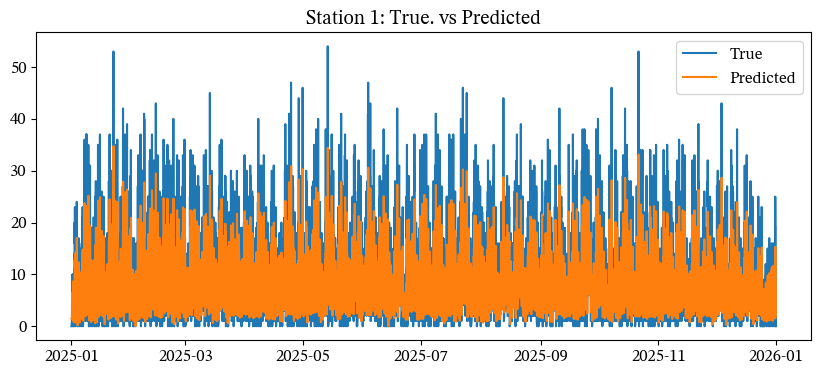

In [13]:
# Station check
sample_station = test_results["station_id"].iloc[0]

temp = test_results[test_results["station_id"] == sample_station].sort_values("datetime_hour")

plt.figure(figsize=(10,4))

plt.plot(temp["datetime_hour"], temp["actual_departures"], label="True")
plt.plot(temp["datetime_hour"], temp["pred_departures_linear"], label="Predicted")

plt.legend()
plt.title(f"Station {sample_station}: True. vs Predicted")
plt.show()

In [14]:
station_errors = test_results.groupby("station_id")[[
    "actual_departures",
    "pred_departures_linear"
]].sum()

station_errors

,actual_departures,pred_departures_linear
station_id,,
1,84837,64388.999751
10,65809,51447.248142
100,14632,16478.372222
102,19817,20354.519064
103,26089,24573.127617
...,...,...
95,26917,24937.585038
96,52611,42521.502769
97,21481,21188.220019


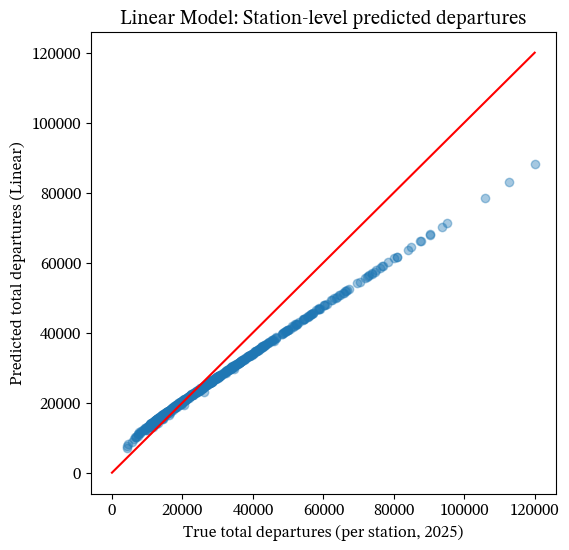

In [15]:
max_val = max(
    station_errors["actual_departures"].max(),
    station_errors["pred_departures_linear"].max()
)

plt.figure(figsize=(6,6))

plt.scatter(
    station_errors["actual_departures"],
    station_errors["pred_departures_linear"],
    alpha=0.4
)

plt.plot([0, max_val], [0, max_val], color="red")

plt.xlabel("True total departures (per station, 2025)")
plt.ylabel("Predicted total departures (Linear)")
plt.title("Linear Model: Station-level predicted departures")

plt.show()

- The linear model is overestimating low demand stations and under estimating high demand stations
- Aggregate total departures show divergences between that are notable (e.g. predicting 10-25k but having 5-20k trips)
- As was seen in the EDA,a small number of stations concentrate trip demand and pull the mean upward

# Poisson Regression

In [16]:
# Fitting and predict model
def tune_poisson(X_train, y_train, X_test, y_test, alphas, iters):
    results = []

    # For finetuning
    for alpha in alphas:
        for max_iter in iters:
            
            model = PoissonRegressor(alpha=alpha, max_iter=max_iter)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)

            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mean_squared_error(y_test, y_pred))

            # To save different regularization outputs
            results.append({
                "alpha": alpha,
                "max_iter": max_iter,
                "MAE": mae,
                "RMSE": rmse,
                "pred_min": y_pred.min(),
                "pred_max": y_pred.max()
            })

    return pd.DataFrame(results).sort_values("RMSE")

In [17]:
alphas = [1, 5, 10, 20]
iters = [300]

poisson_tuning = tune_poisson(
    X_train_scaled, y_train,
    X_test_scaled, y_test,
    alphas, iters
)

poisson_tuning

,alpha,max_iter,MAE,RMSE,pred_min,pred_max
3,20,300,2.963639,4.716429,2.695997,1476.676603
2,10,300,2.884632,6.600389,2.367381,6924.370820
1,5,300,2.830380,8.828959,2.012399,11465.862795
0,1,300,2.740268,10.169193,1.280911,14096.871090


- Poisson has higher prediction error compared to Linear, especially in terms of RMSE
- The exponential link function is producing extreme predictions (as seen in y_pred_poisson min and y_pres_poisson max)
- RMSE penalizes large errors more heavily, so there is more presence of overpredictions
- The bias-variance trade off of a small alpha (1.0) leads to a flexible but unstable prediction, whereas a large alpha (20.0) is more constrained and stable but also more biased
- Even after fine-tuning regularization, the Poisson model are less stable when modeling highly skewed demand; 

In [18]:
# Refitting - best result
poisson_model = PoissonRegressor(alpha=20, max_iter=300)
poisson_model.fit(X_train_scaled, y_train)
y_pred_poisson = poisson_model.predict(X_test_scaled)
test_results["pred_departures_poisson"] = y_pred_poisson

mae_poisson = mean_absolute_error(y_test, y_pred_poisson)
rmse_poisson = np.sqrt(mean_squared_error(y_test, y_pred_poisson))

results.append({
    "model": "Poisson Regression",
    "MAE": mae_poisson,
    "RMSE": rmse_poisson,
    "total_true": y_test.sum(),
    "total_predicted": y_pred_poisson.sum(),
    "bias_pct": (y_pred_poisson.sum() - y_test.sum()) / y_test.sum()
})

results


[{'model': 'Linear Regression',
  'MAE': 2.4656976443635013,
  'RMSE': np.float64(3.695662370303975),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(16920626.344256945),
  'bias_pct': np.float64(-0.09312488996737703)},
 {'model': 'Poisson Regression',
  'MAE': 2.963639194331491,
  'RMSE': np.float64(4.716429412466566),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(14393569.053543875),
  'bias_pct': np.float64(-0.22856463740627697)}]

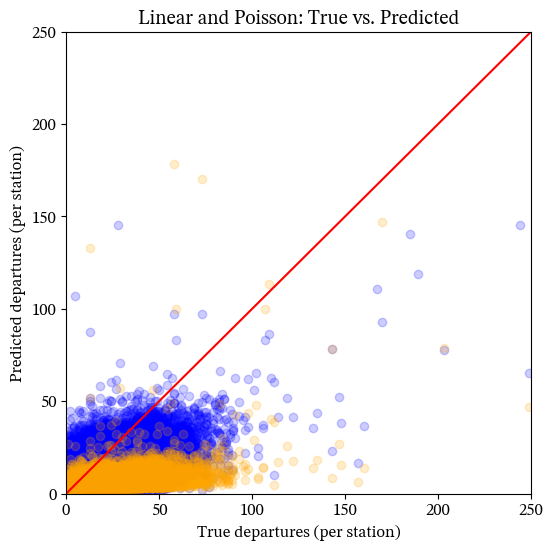

In [19]:
fig, ax = plt.subplots(figsize=(6,6))

# Linear
plt.scatter(
    test_results["actual_departures"],
    test_results["pred_departures_linear"],
    alpha=0.2,
    label="Linear",
    color="blue"
)

# Poisson
plt.scatter(
    test_results["actual_departures"],
    test_results["pred_departures_poisson"],
    alpha=0.2,
    label="Poisson",
    color="orange"
)

max_val = max(
    test_results["actual_departures"].max(),
    test_results["pred_departures_linear"].max(),
    test_results["pred_departures_poisson"].max()
)

plt.plot([0, max_val], [0, max_val], color="red")
plt.xlim(0, 250)
plt.ylim(0, 250)

plt.xlabel("True departures (per station)")
plt.ylabel("Predicted departures (per station)")
plt.title("Linear and Poisson: True vs. Predicted")
fig.savefig("../outputs/plots/linear_poisson_pred.pdf", bbox_inches="tight")
plt.show()

# Tree Based Models

In [20]:
# Helper function for Decision Tree, Random Forest and XGBoost results
def evaluate_predictions(model_name, y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)

    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "total_true": y_true.sum(),
        "total_predicted": y_pred.sum(),
        "bias_pct": (y_pred.sum() - y_true.sum()) / y_true.sum()
    }

In [21]:
# Decision Tree
DT_model = DecisionTreeRegressor(
    max_depth=12,
    min_samples_leaf=50,
    random_state=42
)

DT_model.fit(X_train, y_train)

y_pred_tree = DT_model.predict(X_test)
y_pred_tree = np.clip(y_pred_tree, 0, None)
test_results["pred_departures_DT"] = y_pred_tree

results.append(
    evaluate_predictions("Decision Tree", y_test, y_pred_tree)
)

results

[{'model': 'Linear Regression',
  'MAE': 2.4656976443635013,
  'RMSE': np.float64(3.695662370303975),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(16920626.344256945),
  'bias_pct': np.float64(-0.09312488996737703)},
 {'model': 'Poisson Regression',
  'MAE': 2.963639194331491,
  'RMSE': np.float64(4.716429412466566),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(14393569.053543875),
  'bias_pct': np.float64(-0.22856463740627697)},
 {'model': 'Decision Tree',
  'MAE': 2.3076782957462325,
  'RMSE': np.float64(3.4752326906294546),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(17223652.717732806),
  'bias_pct': np.float64(-0.07688393823204244)}]

- Given the 21m rows, and for computation purposes, a sampling of training data has been implemented for RF & XGBoost

In [22]:
# Random Forest
sample_indices = np.random.choice(len(X_train), 
# 10% of training data (2.1M rows, representative)
    size=int(len(X_train)*0.1), 
    replace=False)

X_sample = X_train.iloc[sample_indices]
y_sample = y_train.iloc[sample_indices]

RF_model = RandomForestRegressor(
    n_estimators=200,        
    max_depth=6,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)
RF_model.fit(X_sample, y_sample)

y_pred_RF = np.clip(RF_model.predict(X_test), 0, None)
test_results["pred_departures_RF"] = y_pred_RF

results.append(
    evaluate_predictions("Random Forest", y_test, y_pred_RF)
)

results

[{'model': 'Linear Regression',
  'MAE': 2.4656976443635013,
  'RMSE': np.float64(3.695662370303975),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(16920626.344256945),
  'bias_pct': np.float64(-0.09312488996737703)},
 {'model': 'Poisson Regression',
  'MAE': 2.963639194331491,
  'RMSE': np.float64(4.716429412466566),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(14393569.053543875),
  'bias_pct': np.float64(-0.22856463740627697)},
 {'model': 'Decision Tree',
  'MAE': 2.3076782957462325,
  'RMSE': np.float64(3.4752326906294546),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(17223652.717732806),
  'bias_pct': np.float64(-0.07688393823204244)},
 {'model': 'Random Forest',
  'MAE': 2.403318303517383,
  'RMSE': np.float64(3.635494232069045),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(17138545.43781594),
  'bias_pct': np.float64(-0.08144533402608069)}]

In [23]:
# XGBoost
XGB_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    tree_method='hist',
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

XGB_model.fit(X_sample, y_sample)

y_pred_XGB = np.clip(XGB_model.predict(X_test), 0, None)
test_results["pred_departures_XGB"] = y_pred_XGB

results.append(
    evaluate_predictions("XGBoost", y_test, y_pred_XGB)
)

results

[{'model': 'Linear Regression',
  'MAE': 2.4656976443635013,
  'RMSE': np.float64(3.695662370303975),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(16920626.344256945),
  'bias_pct': np.float64(-0.09312488996737703)},
 {'model': 'Poisson Regression',
  'MAE': 2.963639194331491,
  'RMSE': np.float64(4.716429412466566),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(14393569.053543875),
  'bias_pct': np.float64(-0.22856463740627697)},
 {'model': 'Decision Tree',
  'MAE': 2.3076782957462325,
  'RMSE': np.float64(3.4752326906294546),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(17223652.717732806),
  'bias_pct': np.float64(-0.07688393823204244)},
 {'model': 'Random Forest',
  'MAE': 2.403318303517383,
  'RMSE': np.float64(3.635494232069045),
  'total_true': np.int64(18658166),
  'total_predicted': np.float64(17138545.43781594),
  'bias_pct': np.float64(-0.08144533402608069)},
 {'model': 'XGBoost',
  'MAE': 2.285095453262329,

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("RMSE").reset_index(drop=True)

results_df["MAE"] = results_df["MAE"].round(3)
results_df["RMSE"] = results_df["RMSE"].round(3)
results_df["total_true"] = results_df["total_true"].round(0).astype(int)
results_df["total_predicted"] = results_df["total_predicted"].round(0).astype(int)
results_df["bias_pct"] = (results_df["bias_pct"] * 100).round(2)

results_df

results_df = results_df.rename(columns={
    "model": "Model",
    "MAE": "MAE",
    "RMSE": "RMSE",
    "total_true": "Total (True)",
    "total_predicted": "Total (Predicted)",
    "bias_pct": "Bias (%)"
})

print(tabulate(
    results_df,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| Model              |   MAE |   RMSE |   Total (True) |   Total (Predicted) |   Bias (%) |
|--------------------|-------|--------|----------------|---------------------|------------|
| XGBoost            | 2.285 |  3.441 |       18658166 |            17118718 |      -8.25 |
| Decision Tree      | 2.308 |  3.475 |       18658166 |            17223653 |      -7.69 |
| Random Forest      | 2.403 |  3.635 |       18658166 |            17138545 |      -8.14 |
| Linear Regression  | 2.466 |  3.696 |       18658166 |            16920626 |      -9.31 |
| Poisson Regression | 2.964 |  4.716 |       18658166 |            14393569 |     -22.86 |


In [38]:
cols_numeric = ["MAE", "RMSE", "Bias (%)", "Total (True)", "Total (Predicted)"]

for col in cols_numeric:
    results_df[col] = pd.to_numeric(results_df[col], errors="coerce")

results_df["MAE"] = results_df["MAE"].round(3)
results_df["RMSE"] = results_df["RMSE"].round(3)
results_df["Bias (%)"] = results_df["Bias (%)"].round(2)

results_df["Total (True)"] = results_df["Total (True)"].astype("Int64").map("{:,}".format)
results_df["Total (Predicted)"] = results_df["Total (Predicted)"].astype("Int64").map("{:,}".format)

latex_table = results_df.to_latex(
    index=False,
    caption="Prediction model performance on the 2025 test set",
    label="tab:prediction_model_performance",
    column_format="lrrrrr",
    escape=False
)

print(latex_table)

\begin{table}
\caption{Prediction model performance on the 2025 test set}
\label{tab:prediction_model_performance}
\begin{tabular}{lrrrrr}
\toprule
Model & MAE & RMSE & Total (True) & Total (Predicted) & Bias (%) \\
\midrule
XGBoost & 2.285000 & 3.441000 & nan & nan & -8.250000 \\
Decision Tree & 2.308000 & 3.475000 & nan & nan & -7.690000 \\
Random Forest & 2.403000 & 3.635000 & nan & nan & -8.140000 \\
Linear Regression & 2.466000 & 3.696000 & nan & nan & -9.310000 \\
Poisson Regression & 2.964000 & 4.716000 & nan & nan & -22.860000 \\
\bottomrule
\end{tabular}
\end{table}



# Best performing model assessment

In [39]:
test_results

,station_id,datetime_hour,departures,arrivals,net_flow,abs_net_flow,year,month,day,hour,...,nearest_metro_name,distance_to_metro_m,lag_1,lag_24,actual_departures,pred_departures_linear,pred_departures_poisson,pred_departures_DT,pred_departures_RF,pred_departures_XGB
44655,1,2025-01-01 00:00:00,0,4,-4,4,2025,1,1,0,...,Constituyentes,573.702169,0.0,10.0,0,1.450212,3.037410,0.692229,0.582355,1.195422
44656,1,2025-01-01 05:00:00,1,3,-2,2,2025,1,1,5,...,Constituyentes,573.702169,0.0,17.0,1,1.516128,3.173418,1.034285,1.082242,1.236095
44657,1,2025-01-01 06:00:00,1,3,-2,2,2025,1,1,6,...,Constituyentes,573.702169,1.0,19.0,1,2.190854,3.300267,1.829087,2.087861,2.418377
44658,1,2025-01-01 07:00:00,2,1,1,1,2025,1,1,7,...,Constituyentes,573.702169,1.0,28.0,2,4.390025,3.705905,1.054614,2.087861,3.550291
44659,1,2025-01-01 08:00:00,2,0,2,2,2025,1,1,8,...,Constituyentes,573.702169,2.0,16.0,2,3.685929,3.413255,1.363636,3.193820,4.159829
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21735181,99,2025-12-31 19:00:00,0,2,-2,2,2025,12,31,19,...,Pasaje Zócalo - Pino Suárez,117.440424,2.0,10.0,0,3.929647,3.673728,3.866332,3.193820,4.322344
21735182,99,2025-12-31 20:00:00,2,5,-3,3,2025,12,31,20,...,Pasaje Zócalo - Pino Suárez,117.440424,0.0,7.0,2,1.292833,3.198765,2.021060,1.793137,2.110694
21735183,99,2025-12-31 21:00:00,2,1,1,1,2025,12,31,21,...,Pasaje Zócalo - Pino Suárez,117.440424,2.0,2.0,2,1.806689,3.199081,1.434962,1.544403,1.563291
21735184,99,2025-12-31 22:00:00,2,1,1,1,2025,12,31,22,...,Pasaje Zócalo - Pino Suárez,117.440424,2.0,8.0,2,2.351330,3.371461,1.917705,1.793094,1.904419


In [40]:
station_errors_xgb = (
    test_results
    .groupby("station_id")[["actual_departures", "pred_departures_XGB"]]
    .sum()
    .reset_index()
)

station_errors_xgb["error"] = (
    station_errors_xgb["actual_departures"] -
    station_errors_xgb["pred_departures_XGB"]
)

station_errors_xgb["error_pct"] = (
    station_errors_xgb["error"] /
    station_errors_xgb["actual_departures"]
)

threshold = station_errors_xgb["actual_departures"].quantile(0.95)

station_errors_xgb["top_5_demand"] = (
    station_errors_xgb["actual_departures"] >= threshold
)

station_errors_xgb.head()

,station_id,actual_departures,pred_departures_XGB,error,error_pct,top_5_demand
0,1,84837,71274.570312,13562.429688,0.159865,True
1,10,65809,55273.402344,10535.597656,0.160094,False
2,100,14632,15378.545898,-746.545898,-0.051021,False
3,102,19817,17979.162109,1837.837891,0.092740,False
4,103,26089,25074.476562,1014.523438,0.038887,False


In [ ]:
station_errors_dt = (
    test_results
    .groupby("station_id")[["actual_departures", "pred_departures_DT"]]
    .sum()
    .reset_index()
)

station_errors_dt["error"] = (
    station_errors_dt["actual_departures"] -
    station_errors_dt["pred_departures_DT"]
)

station_errors_dt["error_pct"] = (
    station_errors_dt["error"] /
    station_errors_dt["actual_departures"]
)

threshold = station_errors_xgb["actual_departures"].quantile(0.95)

station_errors_dt["top_5_demand"] = (
    station_errors_dt["actual_departures"] >= threshold
)

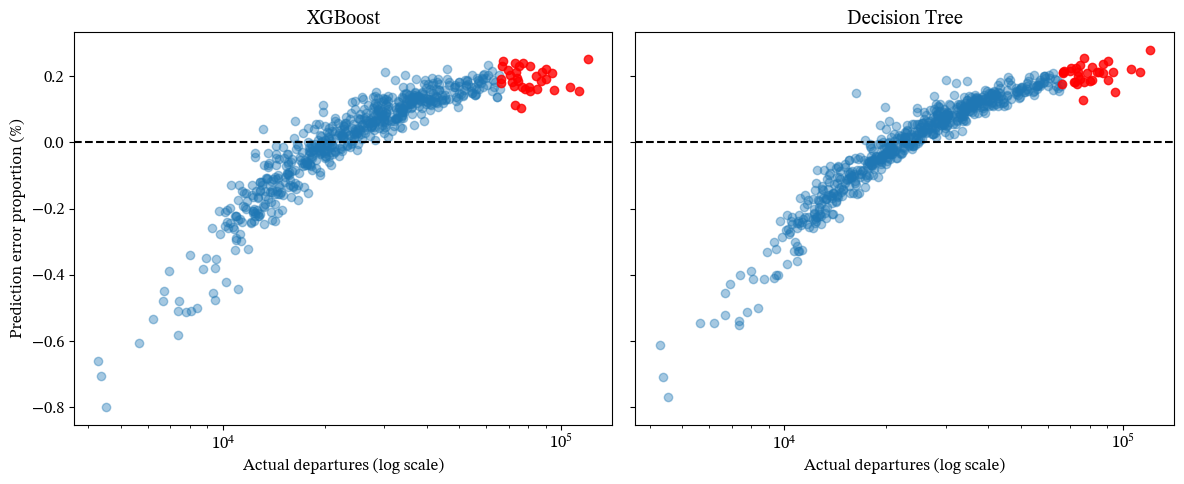

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)

# --- XGBoost ---
regular_xgb = station_errors_xgb[~station_errors_xgb["top_5_demand"]]
top_xgb = station_errors_xgb[station_errors_xgb["top_5_demand"]]

axes[0].scatter(
    regular_xgb["actual_departures"],
    regular_xgb["error_pct"],
    alpha=0.4
)
axes[0].scatter(
    top_xgb["actual_departures"],
    top_xgb["error_pct"],
    color="red",
    alpha=0.8
)

axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xscale("log")
axes[0].set_title("XGBoost")

# --- Decision Tree ---
regular_dt = station_errors_dt[~station_errors_dt["top_5_demand"]]
top_dt = station_errors_dt[station_errors_dt["top_5_demand"]]

axes[1].scatter(
    regular_dt["actual_departures"],
    regular_dt["error_pct"],
    alpha=0.4
)
axes[1].scatter(
    top_dt["actual_departures"],
    top_dt["error_pct"],
    color="red",
    alpha=0.8
)

axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xscale("log")
axes[1].set_title("Decision Tree")

# Labels
for ax in axes:
    ax.set_xlabel("Actual departures (log scale)")

axes[0].set_ylabel("Prediction error share (%)")

plt.tight_layout()
fig.savefig("../outputs/plots/prediction_error_log.pdf", bbox_inches="tight")
plt.show()

- XGBoost has a smoother and more concentrated bias pattern, whereas Decision Tree has greater variability at the tails.
- Results of the best performing model (XGBoost) show that low-demand stations are overestimated while medium-demand stations are nearly unbiased; most the high-demand stations —those in the top 5%— are systematically underestimated.
- Underprediction of the best model, and all other models, has an important implication for prioritization, since the assumption is that this is demand-driven. However, the current model can lead to under-allocation of bikes where they are most needed. This may not fully address the imbalance in ECOBICI.

In [60]:
temp = test_results.copy()

# XGBoost, best performing
temp["error_xgb"] = temp["actual_departures"] - temp["pred_departures_XGB"]
temp["abs_error_xgb"] = temp["error_xgb"].abs()
temp["sq_error_xgb"] = temp["error_xgb"] ** 2

hourly_xgb = (
    temp.groupby("hour")
    .agg(
        MAE=("abs_error_xgb", "mean"),
        RMSE=("sq_error_xgb", lambda x: np.sqrt(x.mean()))
    )
    .reset_index()
)

# Decision Tree as a comparison, less bias
temp["error_dt"] = temp["actual_departures"] - temp["pred_departures_DT"]
temp["abs_error_dt"] = temp["error_dt"].abs()
temp["sq_error_dt"] = temp["error_dt"] ** 2

hourly_dt = (
    temp.groupby("hour")
    .agg(
        MAE=("abs_error_dt", "mean"),
        RMSE=("sq_error_dt", lambda x: np.sqrt(x.mean()))
    )
    .reset_index()
)

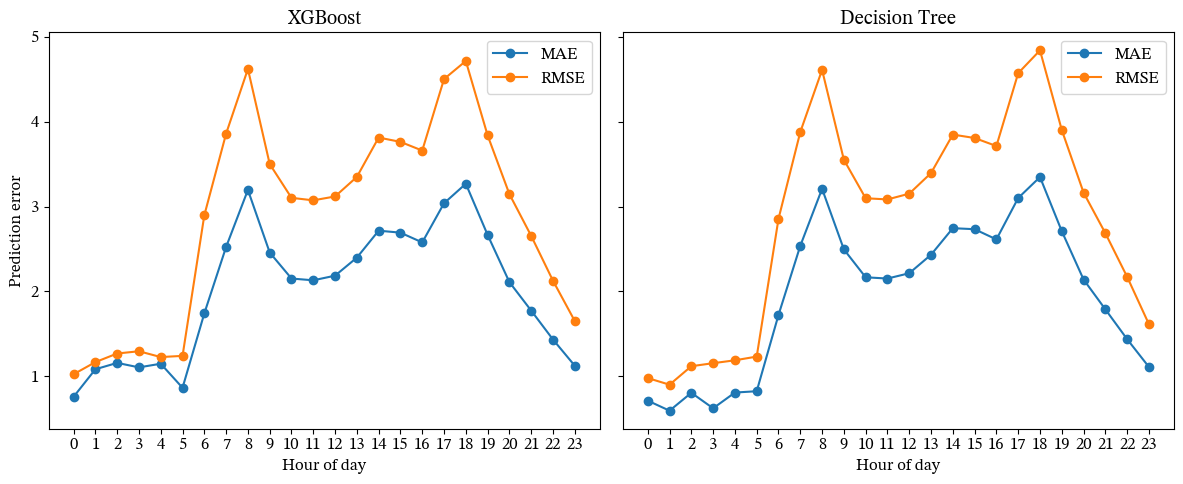

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(hourly_xgb["hour"], hourly_xgb["MAE"], marker="o", label="MAE")
axes[0].plot(hourly_xgb["hour"], hourly_xgb["RMSE"], marker="o", label="RMSE")

axes[0].set_title("XGBoost")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("Prediction error")
axes[0].set_xticks(range(24))
axes[0].legend()

axes[1].plot(hourly_dt["hour"], hourly_dt["MAE"], marker="o", label="MAE")
axes[1].plot(hourly_dt["hour"], hourly_dt["RMSE"], marker="o", label="RMSE")

axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Hour of day")
axes[1].set_xticks(range(24))
axes[1].legend()

plt.tight_layout()
fig.savefig("../outputs/plots/temporal_performance_xgb.pdf", bbox_inches="tight")
plt.show()

In [66]:
# Feature importance comparison
#XGBoost
imp_xgb = pd.Series(
    XGB_model.feature_importances_,
    index=X_train.columns,
    name="XGBoost"
)

# Decision Tree
imp_dt = pd.Series(
    DT_model.feature_importances_,
    index=X_train.columns,
    name="Decision Tree"
)

# Random Forest
imp_rf = pd.Series(
    RF_model.feature_importances_,
    index=X_train.columns,
    name="Random Forest"
)

In [ ]:
imp_df = pd.concat([imp_xgb, imp_dt, imp_rf], axis=1).fillna(0)

# Normalization
imp_df = imp_df.div(imp_df.sum(axis=0), axis=1)

imp_df

,XGBoost,Decision Tree,Random Forest
hour,0.082084,0.129021,0.088923
weekday,0.027937,0.008532,0.003186
is_weekend,0.063627,0.017509,0.002893
is_morning_peak,0.072715,0.007088,0.006085
is_evening_peak,0.050317,0.004131,0.000011
month,0.004775,0.001164,0.000032
lag_1,0.546450,0.760330,0.861785
lag_24,0.063940,0.046186,0.034578
temperature,0.020491,0.001050,0.000427
rain,0.004531,0.000101,0.000000


In [83]:
# For Overleaf 
top_features = imp_df.mean(axis=1).sort_values(ascending=False).head(10).index
table_df = imp_df.loc[top_features].copy()
table_df = table_df.round(3)

table_df = table_df.rename(columns={
    "XGBoost": "XGBoost",
    "Decision Tree": "Decision Tree",
    "Random Forest": "Random Forest"
})

latex_table = table_df.to_latex(
    caption="Feature importance comparison for demand prediction across tree-based models",
    label="tab:feature_importance",
    float_format="%.3f"
)

print(latex_table)

\begin{table}
\caption{Feature importance comparison for demand prediction across tree-based models}
\label{tab:feature_importance}
\begin{tabular}{lrrr}
\toprule
 & XGBoost & Decision Tree & Random Forest \\
\midrule
lag_1 & 0.546 & 0.760 & 0.862 \\
hour & 0.082 & 0.129 & 0.089 \\
lag_24 & 0.064 & 0.046 & 0.035 \\
is_morning_peak & 0.073 & 0.007 & 0.006 \\
is_weekend & 0.064 & 0.018 & 0.003 \\
is_evening_peak & 0.050 & 0.004 & 0.000 \\
distance_to_metro_m & 0.028 & 0.016 & 0.002 \\
weekday & 0.028 & 0.009 & 0.003 \\
capacity & 0.021 & 0.009 & 0.000 \\
temperature & 0.020 & 0.001 & 0.000 \\
\bottomrule
\end{tabular}
\end{table}



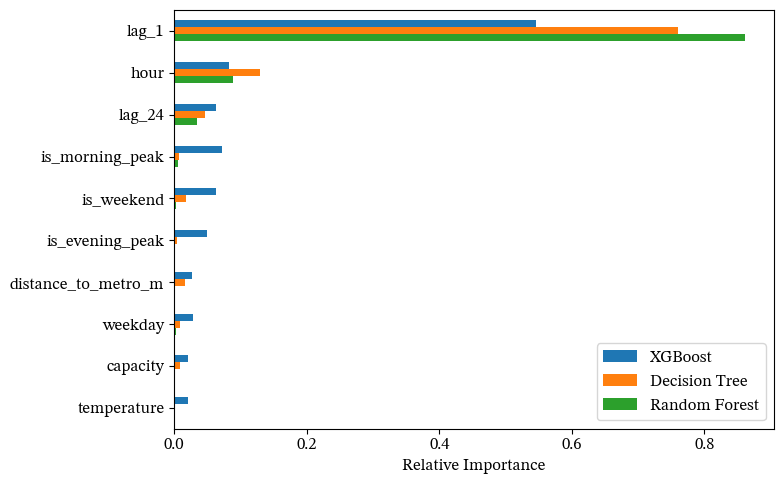

In [81]:
top_features = imp_df.mean(axis=1).sort_values(ascending=False).head(10).index

ax = imp_df.loc[top_features].plot(kind="barh", figsize=(8,5))

ax.invert_yaxis()
ax.set_xlabel("Relative Importance")

fig = ax.get_figure()
fig.tight_layout()
fig.savefig("../outputs/plots/prediction_feature_importance.pdf", bbox_inches="tight")

plt.show()

In [ ]:
test_results.to_parquet(
    "../outputs/model_1_results.parquet",
    index=False)